In [34]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl
import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import datetime
import tqdm 

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from Query.IRSwaps._CENTRAL_BANK_DATES import _CENTRAL_BANK_DATES

In [41]:
bpv_per_trade = +100_000

start = datetime.date(2025, 1, 1)
end = datetime.date(2025, 10, 21)

horizon_period = "3m"
fomc_fly = [1, 2, 3]  # FOMC-i / FOMC-i+1 / FOMC-i+2 fly

FOMC_DATES = [m[0] for m in _CENTRAL_BANK_DATES["USD-FEDFUNDS"].values()]
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)


def resolve_fomc_fly(now: datetime, fly_idxs: list[int], labels=False):
    assert len(fly_idxs) == 3, "its a fly!"

    def _cb_sorted_items(curve: str):
        items = list(_CENTRAL_BANK_DATES[curve].items())
        items.sort(key=lambda kv: kv[1][0])
        return items

    items = _cb_sorted_items("USD-FEDFUNDS")
    idx1 = next((i for i, (_, (s, _e)) in enumerate(items) if s > now), None)
    if idx1 is None or idx1 + 2 >= len(items):
        return None

    if labels:
        return items[idx1 + fly_idxs[0] - 1][0], items[idx1 + fly_idxs[1] - 1][0], items[idx1 + fly_idxs[2] - 1][0]
    return items[idx1 + fly_idxs[0] - 1][1][0], items[idx1 + fly_idxs[1] - 1][1][0], items[idx1 + fly_idxs[2] - 1][1][0]

In [42]:
def compute_pay_belly_2s5s10s_carry(bt: QueryDrivenBacktest, now: datetime.date) -> float | None:
	try:
		q_carry = IRSwapQuery(
			structure=IRSwapStructure.FLY,
			curve="USD-SOFR-1D",
			structure_kwargs={"front_tenor": "2Y", "belly_tenor": "5Y", "back_tenor": "10Y", "bpv": -abs(100_000)},
		)
		pricer_or_curve = bt._pricer_for_query(q_carry, now)
		pkg, rws = q_carry.resolve_package(pricer_or_curve=pricer_or_curve)
		vmap = q_carry.build_value_map(pricer_or_curve=pricer_or_curve, package=pkg, risk_weights=rws)
		print(vmap.apply(value=IRSwapValue.CARRY_BPS_RUNNING, **{"horizon": horizon_period}))
		return vmap.apply(value=IRSwapValue.CARRY_BPS_RUNNING, **{"horizon": horizon_period})
	except Exception as e:
		print(now, e)

In [43]:
mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-rl_basic")
tg = TimeGrid(ql_cal_date_range(ql_cal=CAL, start=start, end=end))

bt_boot = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=QueryStrategy(name="boot", triggers=[]))

In [44]:
daily = list(tg)

carry_map: dict[datetime.date, float] = {}
for d in tqdm.tqdm(daily, desc="CALC HIST CARRY SIGNAL..."):
    c = compute_pay_belly_2s5s10s_carry(bt_boot, d)
    if c is not None:
        carry_map[d] = c


def first_non_positive_after(d0: datetime.date) -> datetime.date | None:
    for d in daily:
        d = d.date()
        if d <= d0:
            continue
        v = carry_map.get(d)
        if v is not None and v <= 0:
            return d
    return None


def one_business_day_before(dt_py) -> datetime.date:
    qd = ql.Date(dt_py.day, dt_py.month, dt_py.year)
    prev = CAL.advance(qd, -1, ql.Days)
    return datetime.date(prev.year(), prev.month(), prev.dayOfMonth())


episodes: list[tuple[datetime.date, datetime.date, str]] = []
in_pos = False
planned_exit: datetime.date | None = None

for d in daily:
    d = pd.Timestamp(d)
    sig = carry_map.get(d, float("nan")) > 0

    # leave if we've passed the planned exit
    if in_pos and planned_exit is not None and d.date() >= planned_exit:
        in_pos = False
        planned_exit = None

    if (not in_pos) and sig:
        lbls = resolve_fomc_fly(d.date(), fomc_fly, labels=True)
        if lbls is None:
            continue
        k1, k2, k3 = lbls

        # FIRST LEG expiry = end date of k1; unwind 1B before that
        k1_start, k1_end = _CENTRAL_BANK_DATES["USD-FEDFUNDS"][k1]
        pre_expiry = one_business_day_before(k1_end)

        # Carry-based early exit
        flip = first_non_positive_after(d.date())

        # Choose earliest available exit strictly after entry
        candidates = [x for x in (pre_expiry, flip) if x is not None and x > d.date()]
        if not candidates:
            continue
        exit_d = min(candidates)

        tag = f"fomc-gapfly-{d:%Y%m%d}"
        episodes.append((d.date(), exit_d, tag))
        in_pos = True
        planned_exit = exit_d


triggers = []
for entry_date, exit_date, tag in episodes:
    fly = resolve_fomc_fly(entry_date, fomc_fly, labels=True)
    if fly is None:
        continue

    q_fomc_fly = IRSwapQuery(
        structure=IRSwapStructure.FLY,
        value=IRSwapValue.NPV,
        curve="USD-SOFR-1D",
        structure_kwargs={
            "front_tenor": fly[0],
            "belly_tenor": fly[1],
            "back_tenor": fly[2],
            "bpv": +abs(bpv_per_trade),
        },
        tags=(tag,),
    )

    enter = DateTrigger(DateTriggerRequirements(dates=[entry_date]), actions=[AddQueryAction(query=q_fomc_fly)])
    exit_ = DateTrigger(DateTriggerRequirements(dates=[exit_date]), actions=[UnwindPositionsAction(match_tag=tag, fee=0.0)])
    triggers.extend([enter, exit_])

CALC HIST CARRY SIGNAL...:   1%|▏         | 3/201 [00:00<00:08, 23.31it/s]

-1.6678252981922732
-1.4894951521669804
-1.6548182093611277
-1.681151162825842
-1.789209819143406
-1.9239260264222735


CALC HIST CARRY SIGNAL...:   6%|▌         | 12/201 [00:00<00:07, 26.25it/s]

-1.3820508941315979
-1.4851413774118196
-1.6503746709141398
-1.7680802521821697
-1.7914348139747016
-1.5655692209347318


CALC HIST CARRY SIGNAL...:   9%|▉         | 18/201 [00:00<00:06, 26.52it/s]

...

-3.5416273022682163
-3.610492858809946
-3.527984561575715
-3.4516517781497944
-3.3465412366957823
-3.217040428543649


CALC HIST CARRY SIGNAL...:  99%|█████████▊| 198/201 [00:07<00:00, 26.51it/s]

-3.5598982488992115
-3.828457955621091
-3.7879868514938817
-3.9658108544857535
-3.941700631068037
-3.84676618286537


CALC HIST CARRY SIGNAL...: 100%|██████████| 201/201 [00:07<00:00, 25.43it/s]

-3.8427923458755204


In [45]:
final_strategy = QueryStrategy(name="FOMC Meeting Gap Fly", triggers=triggers)
bt = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=final_strategy)
bt.run()

BACKTESTING...: 100%|██████████| 201/201 [00:00<00:00, 1009646.83step/s]


Final MTM: 0.0


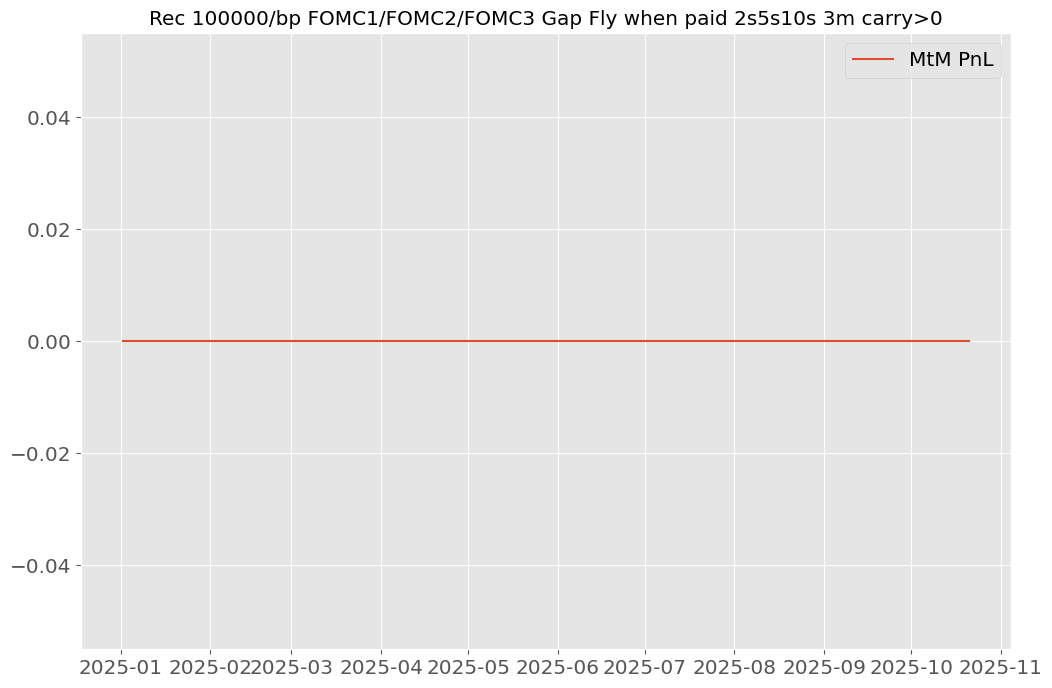

In [46]:
mtm = pd.Series(bt.mtm_history).sort_index()
print("Final MTM:", float(mtm.iloc[-1]))

plt.figure()
plt.plot(mtm.index, mtm.values, label="MtM PnL")
plt.legend()
plt.title(f"Rec {bpv_per_trade}/bp FOMC{fomc_fly[0]}/FOMC{fomc_fly[1]}/FOMC{fomc_fly[2]} Gap Fly when paid 2s5s10s {horizon_period} carry>0")
plt.show()